<a href="https://colab.research.google.com/github/Abdulrahman-Mahmoud-12/ENDO-X/blob/osama/ENDOX_Exp7_YOLO26s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U ultralytics -q

import os, zipfile

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d debeshjha1/kvasirseg

with zipfile.ZipFile('kvasirseg.zip', 'r') as zip_ref:
  zip_ref.extractall('kvasir')

print(os.listdir('kvasir/Kvasir-SEG/Kvasir-SEG'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.9 MB/s eta 0:00:00
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirseg
License(s): copyright-authors
100% 144M/144M [00:00<00:00, 183MB/s]

['annotated_images', 'masks', 'images', 'bbox', '1911.07069.pdf']


In [ ]:
import os, cv2, csv, shutil, random, yaml, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import torch

print('GPU:', torch.cuda.is_available())
if torch.cuda.is_available():
  print(torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
GPU: True
Tesla T4


In [ ]:
IMAGE_DIR = 'kvasir/Kvasir-SEG/Kvasir-SEG/images'
CSV_DIR   = 'kvasir/Kvasir-SEG/Kvasir-SEG/bbox'

all_keys = [f.replace('.jpg', '') for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

print('Total images:', len(all_keys))

with open(os.path.join(CSV_DIR, all_keys[0] + '.csv'), 'r') as f:
  print(f.read())

Total images: 1000
class_name,xmin,ymin,xmax,ymax
polyp,372,226,607,389



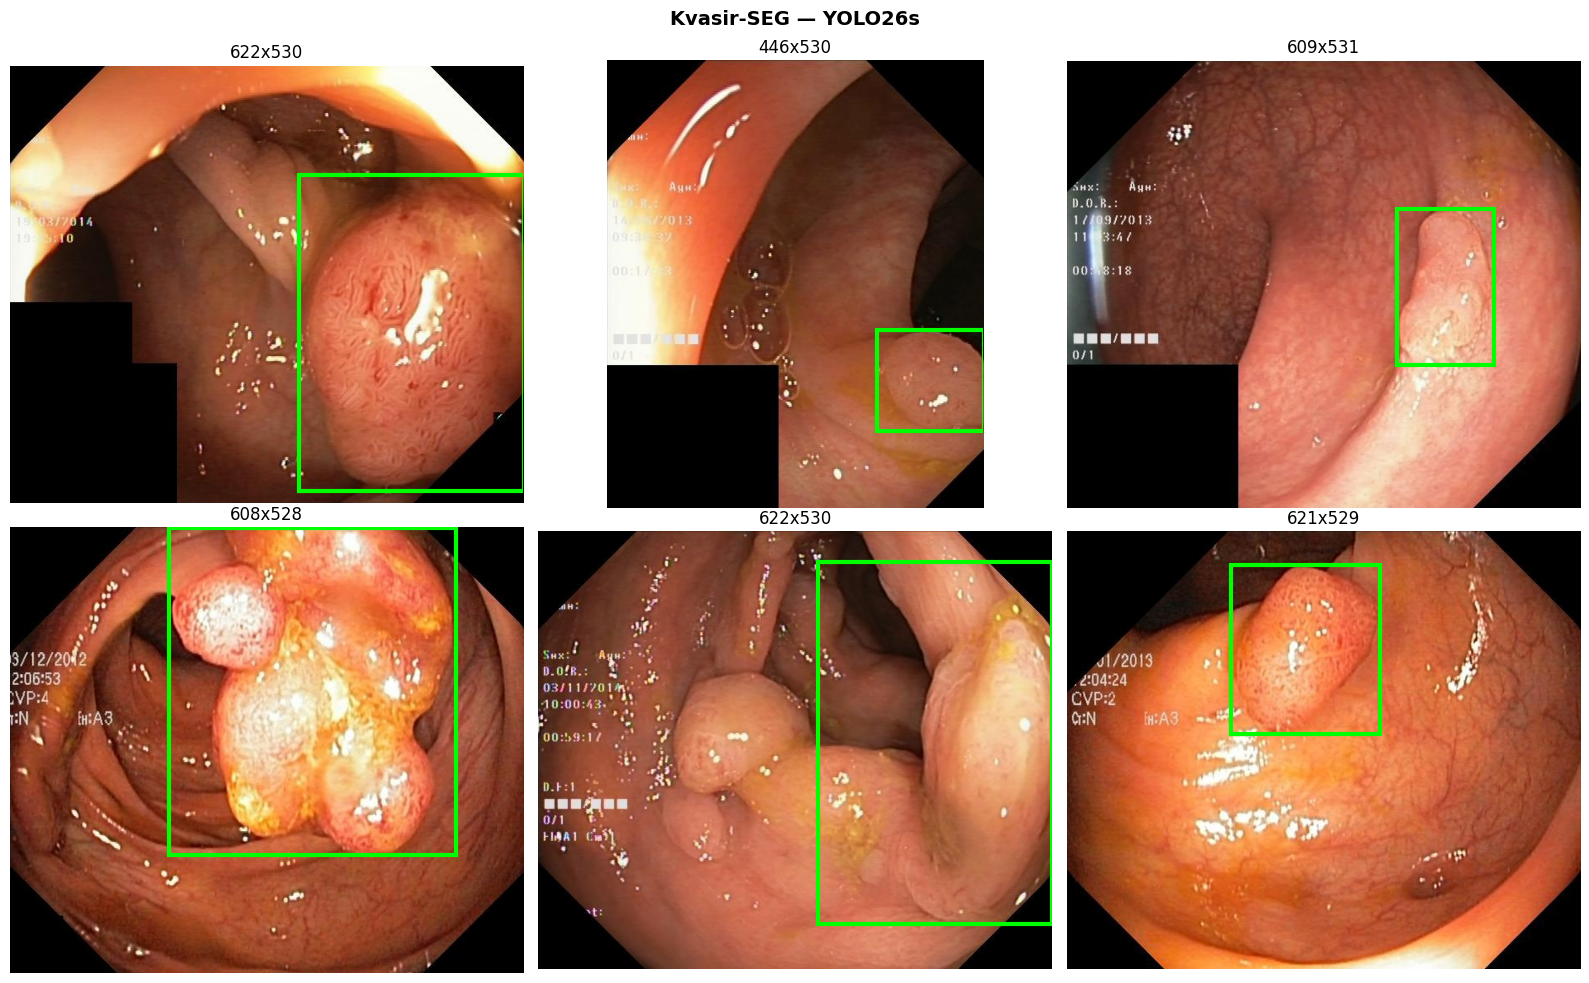

In [ ]:
sample_keys = random.sample(all_keys, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Kvasir-SEG — YOLO26s', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, key in enumerate(sample_keys):
  img = cv2.imread(os.path.join(IMAGE_DIR, key + '.jpg'))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  with open(os.path.join(CSV_DIR, key + '.csv'), 'r') as f:
    row = next(csv.DictReader(f))

  bx = float(row['xmin'])
  by = float(row['ymin'])
  bw = float(row['xmax']) - bx
  bh = float(row['ymax']) - by

  axes[i].imshow(img)
  axes[i].add_patch(patches.Rectangle((bx, by), bw, bh, linewidth=3, edgecolor='lime', facecolor='none'))
  axes[i].set_title(f'{img.shape[1]}x{img.shape[0]}')
  axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def read_bbox_csv(csv_path, img_w, img_h):
  with open(csv_path, 'r') as f:
    row = next(csv.DictReader(f))
  x1 = float(row['xmin']);  y1 = float(row['ymin'])
  x2 = float(row['xmax']);  y2 = float(row['ymax'])
  bw = x2 - x1;             bh = y2 - y1
  cx = max(0., min(1., (x1 + bw / 2) / img_w))
  cy = max(0., min(1., (y1 + bh / 2) / img_h))
  nw = max(0., min(1., bw / img_w))
  nh = max(0., min(1., bh / img_h))
  return f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}'


BASE = 'dataset'
for split in ['train', 'val', 'test']:
  os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
  os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

train_keys, temp_keys = train_test_split(all_keys, test_size=0.30, random_state=42)
val_keys,   test_keys = train_test_split(temp_keys, test_size=0.50, random_state=42)

print(f'Train:{len(train_keys)} | Val:{len(val_keys)} | Test:{len(test_keys)}')

def build_split(keys, split_name):
  for key in keys:
    img_path = os.path.join(IMAGE_DIR, key + '.jpg')
    csv_path = os.path.join(CSV_DIR,   key + '.csv')
    img      = cv2.imread(img_path)
    h, w     = img.shape[:2]
    shutil.copy(img_path, f'{BASE}/images/{split_name}/{key}.jpg')
    with open(f'{BASE}/labels/{split_name}/{key}.txt', 'w') as f:
      f.write(read_bbox_csv(csv_path, w, h) + '\n')

build_split(train_keys, 'train')
build_split(val_keys,   'val')
build_split(test_keys,  'test')

print('Done')
print('images/train:', len(os.listdir(f'{BASE}/images/train')))
print('labels/train:', len(os.listdir(f'{BASE}/labels/train')))

Train:700 | Val:150 | Test:150
Done
images/train: 700
labels/train: 700


In [ ]:
dataset_yaml = {
    'path' : '/content/dataset',
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : 1,
    'names': ['polyp']
}

yaml_path = 'kvasir_detection.yaml'
with open(yaml_path, 'w') as f:
  yaml.dump(dataset_yaml, f, default_flow_style=False)

with open(yaml_path, 'r') as f:
  print(f.read())

names:
- polyp
nc: 1
path: /content/dataset
test: images/test
train: images/train
val: images/val



In [ ]:
MODEL_SIZE    = 'yolo26s.pt'
IMG_SIZE      = 640
EPOCHS        = 100
BATCH_SIZE    = 16
LR0           = 0.005
LRF           = 0.0005
WARMUP_EPOCHS = 5
PATIENCE      = 30
CLOSE_MOSAIC  = 15
CONF_THRESH   = 0.15
IOU_THRESH    = 0.35

print(f'Model       : yolo26s.pt')
print(f'Epochs      : {EPOCHS}')
print(f'Batch       : {BATCH_SIZE}')
print(f'LR          : {LR0} → {LRF}')
print(f'Conf thresh : {CONF_THRESH}')
print(f'IoU thresh  : {IOU_THRESH}')

Model       : yolo26s.pt
Epochs      : 100
Batch       : 16
LR          : 0.005 → 0.0005
Conf thresh : 0.15
IoU thresh  : 0.35


In [ ]:
model = YOLO(MODEL_SIZE)
print(f'Params: {sum(p.numel() for p in model.model.parameters()):,}')

Params: 10,009,784


In [ ]:
results = model.train(
    data          = yaml_path,
    epochs        = EPOCHS,
    imgsz         = IMG_SIZE,
    batch         = BATCH_SIZE,
    lr0           = LR0,
    lrf           = LRF,
    warmup_epochs = WARMUP_EPOCHS,
    patience      = PATIENCE,
    close_mosaic  = CLOSE_MOSAIC,
    optimizer     = 'Adam',
    cos_lr        = True,
    augment       = True,
    mosaic        = 1.0,
    mixup         = 0.15,
    degrees       = 15.0,
    scale         = 0.6,
    shear         = 2.0,
    fliplr        = 0.5,
    flipud        = 0.3,
    hsv_h         = 0.02,
    hsv_s         = 0.8,
    hsv_v         = 0.5,
    save          = True,
    project       = 'ENDOX_runs',
    name          = 'exp7_yolo26s',
    verbose       = True
)

print('Done')

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=kvasir_detection.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.0005, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp7_yolo26s, nbs=64, nms=False, opse

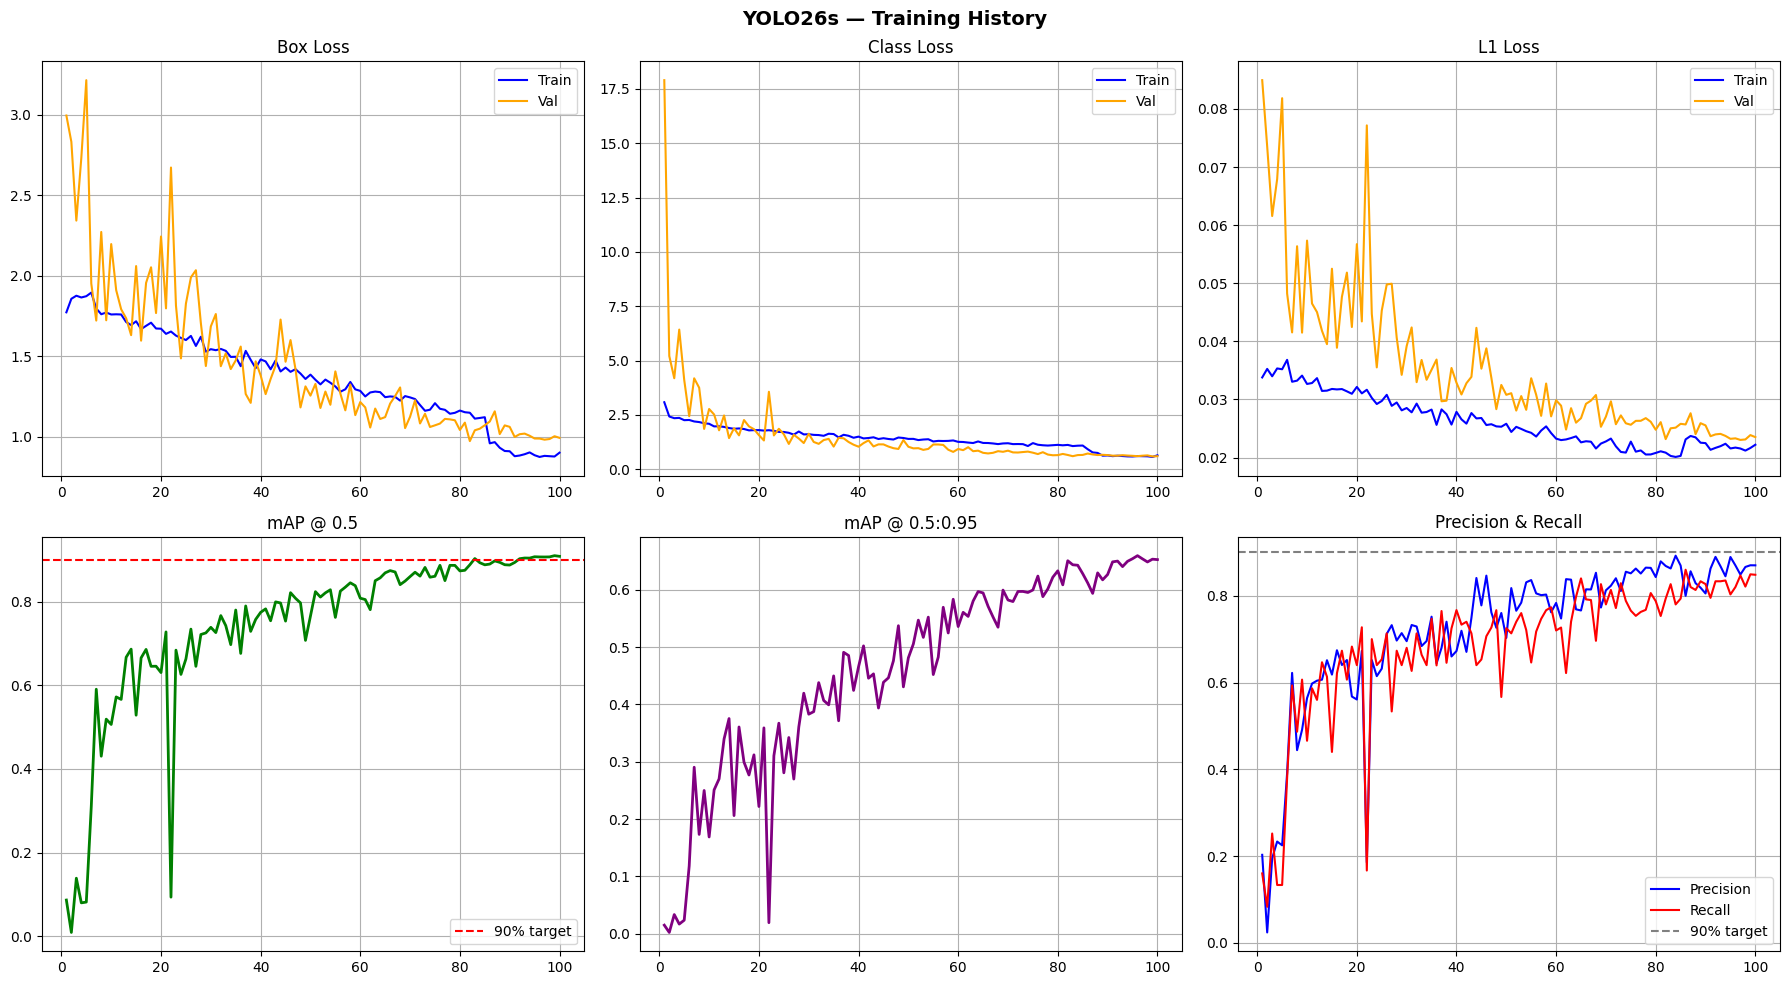

In [ ]:
df = pd.read_csv('/content/runs/detect/ENDOX_runs/exp7_yolo26s/results.csv')
df.columns = df.columns.str.strip()
epochs = df['epoch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLO26s — Training History', fontsize=14, fontweight='bold')

axes[0,0].plot(epochs, df['train/box_loss'], label='Train', color='blue')
axes[0,0].plot(epochs, df['val/box_loss'],   label='Val',   color='orange')
axes[0,0].set_title('Box Loss');  axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(epochs, df['train/cls_loss'], label='Train', color='blue')
axes[0,1].plot(epochs, df['val/cls_loss'],   label='Val',   color='orange')
axes[0,1].set_title('Class Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(epochs, df['train/l1_loss'], label='Train', color='blue')
axes[0,2].plot(epochs, df['val/l1_loss'],   label='Val',   color='orange')
axes[0,2].set_title('L1 Loss');  axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].plot(epochs, df['metrics/mAP50(B)'], color='green', linewidth=2)
axes[1,0].axhline(0.90, color='red', linestyle='--', label='90% target')
axes[1,0].set_title('mAP @ 0.5'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(epochs, df['metrics/mAP50-95(B)'], color='purple', linewidth=2)
axes[1,1].set_title('mAP @ 0.5:0.95'); axes[1,1].grid(True)

axes[1,2].plot(epochs, df['metrics/precision(B)'], label='Precision', color='blue')
axes[1,2].plot(epochs, df['metrics/recall(B)'],    label='Recall',    color='red')
axes[1,2].axhline(0.90, color='gray', linestyle='--', label='90% target')
axes[1,2].set_title('Precision & Recall'); axes[1,2].legend(); axes[1,2].grid(True)

plt.tight_layout()
plt.savefig('exp7_yolo26s_curves.png', dpi=150)
plt.show()

In [ ]:
best_model = YOLO('/content/runs/detect/ENDOX_runs/exp7_yolo26s/weights/best.pt')

metrics = best_model.val(
    data    = yaml_path,
    split   = 'test',
    imgsz   = IMG_SIZE,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    verbose = True
)

print(f'mAP@0.5   : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)')
print(f'mAP@0.5:95: {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')

exp_results = {
    'experiment': 'Exp 7',
    'model'     : 'YOLO26s',
    'mAP50'     : round(metrics.box.map50, 4),
    'mAP50_95'  : round(metrics.box.map,   4),
    'precision' : round(metrics.box.mp,    4),
    'recall'    : round(metrics.box.mr,    4)
}
with open('exp7_results.json', 'w') as f:
  json.dump(exp_results, f)

print('exp7_results.json saved')

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 7.7±1.6 MB/s, size: 53.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/dataset/labels/test... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 452.4it/s 0.3s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.2it/s 3.2s
                   all        150        150      0.888      0.847      0.884      0.595
Speed: 3.6ms preprocess, 9.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5   : 0.8836  (88.36%)
mAP@0.5:95: 0.5950
Precision : 0.8877
Recall 

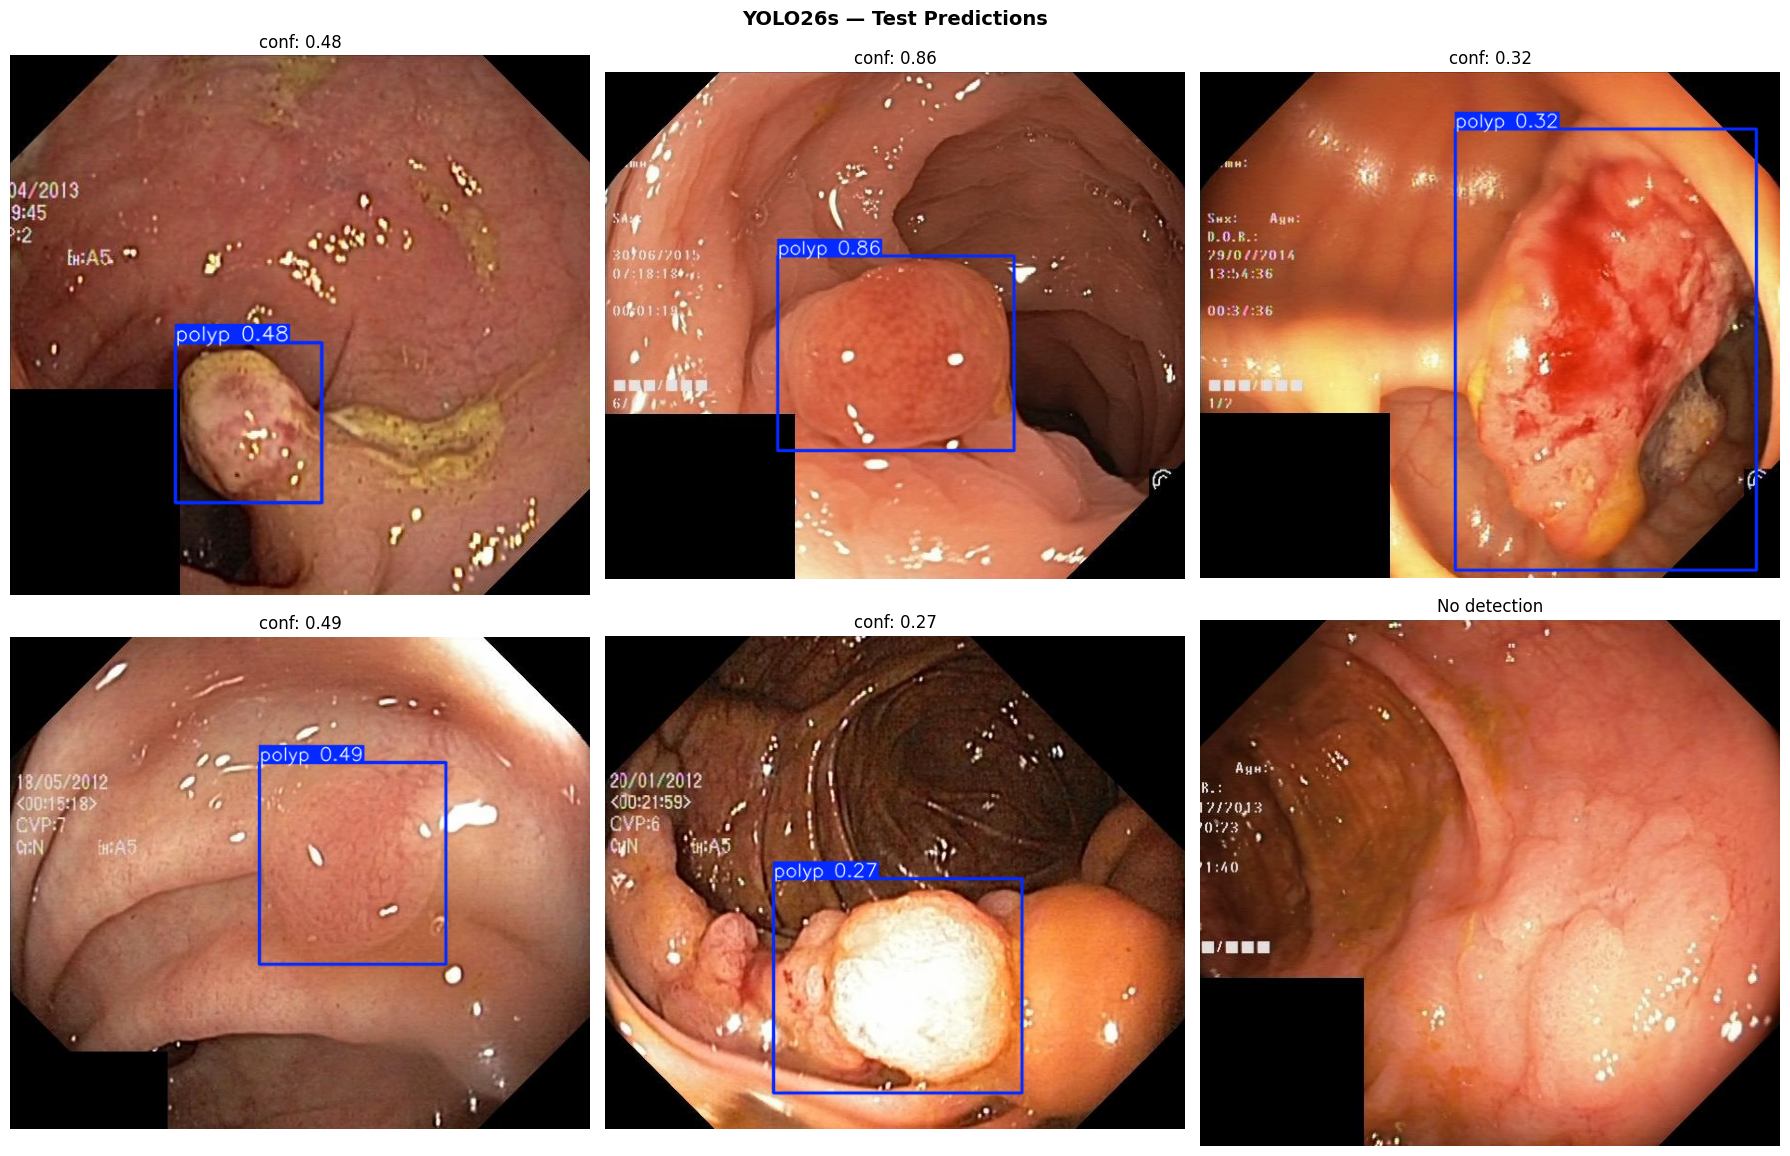

In [ ]:
test_img_dir = f'{BASE}/images/test'
test_images  = random.sample(os.listdir(test_img_dir), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('YOLO26s — Test Predictions', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, fname in enumerate(test_images):
  result = best_model.predict(
      source  = os.path.join(test_img_dir, fname),
      conf    = CONF_THRESH,
      iou     = IOU_THRESH,
      verbose = False
  )[0]

  plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
  boxes   = result.boxes
  title   = f'conf: {boxes.conf[0].item():.2f}' if len(boxes) > 0 else 'No detection'

  axes[i].imshow(plotted)
  axes[i].set_title(title)
  axes[i].axis('off')

plt.tight_layout()
plt.savefig('exp7_yolo26s_predictions.png', dpi=150)
plt.show()

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2186.8±635.5 MB/s, size: 62.4 KB)
val: Scanning /content/dataset/labels/test.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.7s
                   all        150        150      0.888      0.847      0.899      0.605
Speed: 5.4ms preprocess, 8.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-2
conf=0.10 | mAP50=0.8994 | Precision=0.8877 | Recall=0.8467
Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1917.1±443.5 MB/s, size: 60.6 KB)
val: Scanning /content/dataset/labels/test.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 57.2Mit/s 0.0s


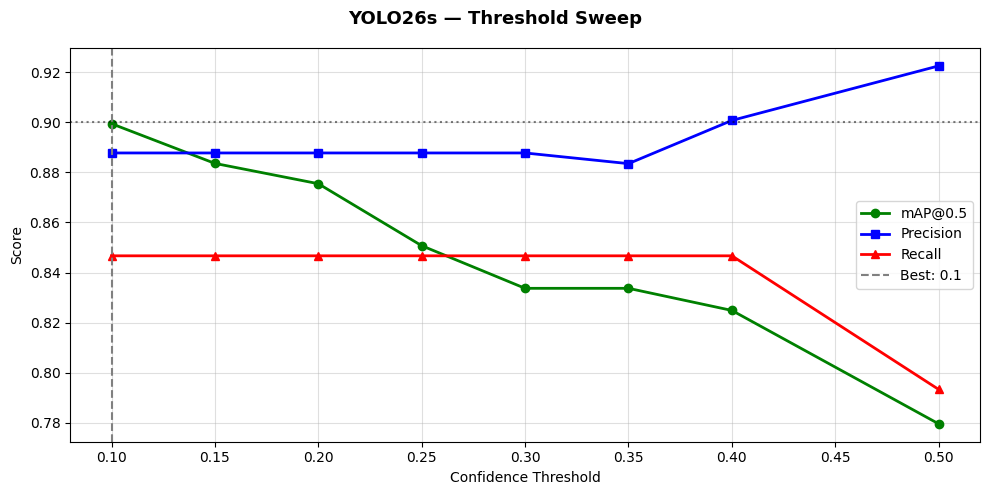

In [ ]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
recalls    = []
precisions = []
maps       = []

for thresh in thresholds:
  m = best_model.val(
      data=yaml_path, split='test',
      imgsz=IMG_SIZE, conf=thresh, iou=IOU_THRESH, verbose=False
  )
  recalls.append(m.box.mr)
  precisions.append(m.box.mp)
  maps.append(m.box.map50)
  print(f'conf={thresh:.2f} | mAP50={m.box.map50:.4f} | Precision={m.box.mp:.4f} | Recall={m.box.mr:.4f}')

best_idx    = maps.index(max(maps))
best_thresh = thresholds[best_idx]
print(f'Best threshold: {best_thresh} (mAP={maps[best_idx]:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('YOLO26s — Threshold Sweep', fontsize=13, fontweight='bold')
ax.plot(thresholds, maps,       label='mAP@0.5',  color='green', linewidth=2, marker='o')
ax.plot(thresholds, precisions, label='Precision', color='blue',  linewidth=2, marker='s')
ax.plot(thresholds, recalls,    label='Recall',    color='red',   linewidth=2, marker='^')
ax.axvline(best_thresh, color='gray', linestyle='--', label=f'Best: {best_thresh}')
ax.axhline(0.90, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('exp7_yolo26s_sweep.png', dpi=150)
plt.show()

In [ ]:
shutil.copy('/content/runs/detect/ENDOX_runs/exp7_yolo26s/weights/best.pt', 'endox_exp7_yolo26s.pt')
print('Saved: endox_exp7_yolo26s.pt')

from google.colab import files
files.download('endox_exp7_yolo26s.pt')
files.download('exp7_results.json')
files.download('exp7_yolo26s_sweep.png')

Saved: endox_exp7_yolo26s.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>